<a href="https://colab.research.google.com/github/SammyBoi242006/CCPS_project/blob/main/gradcam%2B%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted!")

!pip install albumentations timm grad-cam -q
print("Done!")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 60.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Done!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print(f"PyTorch: {torch.__version__}")
print(f"GPU    : {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

PyTorch: 2.11.0+cu128
GPU    : True
Device : cuda


In [3]:
PLANTVILLAGE = '/content/drive/MyDrive/project/data/plantvillage_tomato/PlantVillage'
RESULTS      = '/content/drive/MyDrive/project/results'
MODELS       = '/content/drive/MyDrive/project/models'
GRADCAM_DIR  = os.path.join(RESULTS, 'gradcam')
os.makedirs(GRADCAM_DIR, exist_ok=True)

SELECTED_CLASSES = [
    'Tomato_healthy',
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato__Tomato_YellowLeaf__Curl_Virus'
]

short_names  = ['Healthy', 'Bacterial Spot', 'Early Blight',
                'Late Blight', 'Yellow Leaf Curl']

class_to_idx = {cls: idx for idx, cls in enumerate(SELECTED_CLASSES)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

CONFIG = {
    'image_size': 224,
    'num_classes': 5,
    'mean': [0.485, 0.456, 0.406],
    'std' : [0.229, 0.224, 0.225],
}

print("Config ready.")

Config ready.


In [4]:
class MultiScaleStem(nn.Module):
    def __init__(self):
        super().__init__()
        self.branch_3x3 = nn.Sequential(
            nn.Conv2d(3, 21, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(21), nn.ReLU()
        )
        self.branch_5x5 = nn.Sequential(
            nn.Conv2d(3, 21, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm2d(21), nn.ReLU()
        )
        self.branch_7x7 = nn.Sequential(
            nn.Conv2d(3, 22, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm2d(22), nn.ReLU()
        )
        self.compress = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU()
        )

    def forward(self, x):
        return self.compress(torch.cat([
            self.branch_3x3(x),
            self.branch_5x5(x),
            self.branch_7x7(x)
        ], dim=1))


class SEModule(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.se(x).view(x.size(0), x.size(1), 1, 1)


class DepthwiseSeparableBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2, use_se=False):
        super().__init__()
        self.dw = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1,
                      groups=in_ch, bias=False),
            nn.GroupNorm(min(32, in_ch), in_ch), nn.ReLU()
        )
        self.pw = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.GroupNorm(min(32, out_ch), out_ch), nn.ReLU()
        )
        self.se      = SEModule(out_ch) if use_se else nn.Identity()
        self.dropout = nn.Dropout2d(0.1)

    def forward(self, x):
        return self.dropout(self.se(self.pw(self.dw(x))))


class CNNBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem   = MultiScaleStem()
        self.block1 = DepthwiseSeparableBlock(64,  128, use_se=False)
        self.block2 = DepthwiseSeparableBlock(128, 256, use_se=True)
        self.block3 = DepthwiseSeparableBlock(256, 512, use_se=False)
        self.gem_p  = nn.Parameter(torch.ones(1) * 3.0)
        self.flat   = nn.Flatten()

    def gem_pool(self, x):
        return x.clamp(min=1e-6).pow(self.gem_p).mean(dim=[2,3]).pow(1.0/self.gem_p)

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gem_pool(x)
        return self.flat(x)


class CAFormerBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.caformer = timm.create_model(
            'caformer_s18', pretrained=False, num_classes=0
        )

    def forward(self, x):
        return self.caformer(x)


class CBSEF(nn.Module):
    def __init__(self, feature_dim=1024, reduction=16):
        super().__init__()
        self.se_gate = nn.Sequential(
            nn.Linear(feature_dim, feature_dim // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(feature_dim // reduction, feature_dim, bias=False),
            nn.Sigmoid()
        )

    def forward(self, cnn_feat, trans_feat):
        combined = torch.cat([cnn_feat, trans_feat], dim=1)
        gate     = self.se_gate(combined)
        return combined * gate + combined


class FullHybridModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.cnn_branch   = CNNBranch()
        self.trans_branch = CAFormerBranch()
        self.fusion       = CBSEF(feature_dim=1024, reduction=16)
        self.classifier   = nn.Sequential(
            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        cnn_feat   = self.cnn_branch(x)
        trans_feat = self.trans_branch(x)
        fused      = self.fusion(cnn_feat, trans_feat)
        return self.classifier(fused)

model = FullHybridModel(num_classes=CONFIG['num_classes']).to(device)
print("Model architecture rebuilt.")

Model architecture rebuilt.


In [5]:
checkpoint = torch.load(
    os.path.join(MODELS, 'best_hybrid_v2.pth'),
    map_location=device
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Model loaded! PlantVillage Val Acc: {checkpoint['val_acc']:.2f}%")
print(f"Learned GeM p: {model.cnn_branch.gem_p.item():.4f}")

Model loaded! PlantVillage Val Acc: 99.69%
Learned GeM p: 2.9402


In [ ]:
#####Image PreProcessing====#

In [6]:
preprocess = A.Compose([
    A.Resize(CONFIG['image_size'], CONFIG['image_size']),
    A.Normalize(mean=CONFIG['mean'], std=CONFIG['std']),
    ToTensorV2()
])

def load_image(img_path):
    """Load image and return both tensor and RGB array for visualization."""
    img_rgb = np.array(Image.open(img_path).convert('RGB'))
    img_rgb = cv2.resize(img_rgb, (CONFIG['image_size'], CONFIG['image_size']))

    # Normalized tensor for model input
    tensor = preprocess(image=img_rgb)['image']
    tensor = tensor.unsqueeze(0).to(device)

    # Float array 0-1 for heatmap overlay
    img_float = img_rgb.astype(np.float32) / 255.0

    return tensor, img_float

print("Preprocessing ready.")

Preprocessing ready.


In [7]:
sample_images = {}

for cls in SELECTED_CLASSES:
    cls_path = os.path.join(PLANTVILLAGE, cls)
    # Pick the first image from each class
    for img_file in sorted(os.listdir(cls_path)):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            sample_images[cls] = os.path.join(cls_path, img_file)
            break

print("Sample images selected:")
for cls, path in sample_images.items():
    print(f"  {cls}: {os.path.basename(path)}")

Sample images selected:
  Tomato_healthy: 000146ff-92a4-4db6-90ad-8fce2ae4fddd___GH_HL Leaf 259.1.JPG
  Tomato_Bacterial_spot: 00416648-be6e-4bd4-bc8d-82f43f8a7240___GCREC_Bact.Sp 3110.JPG
  Tomato_Early_blight: 0012b9d2-2130-4a06-a834-b1f3af34f57e___RS_Erly.B 8389.JPG
  Tomato_Late_blight: 0003faa8-4b27-4c65-bf42-6d9e352ca1a5___RS_Late.B 4946.JPG
  Tomato__Tomato_YellowLeaf__Curl_Virus: 00139ae8-d881-4edb-925f-46584b0bd68c___YLCV_NREC 2944.JPG


In [12]:
# CNN target — last depthwise conv in block3
cnn_target_layer = [model.cnn_branch.block3.dw[0]]

# CAFormer target — use the last stage's norm layer
# Transformer blocks need special handling for Grad-CAM
caformer_target_layer = [model.trans_branch.caformer.stages[3]]

print("Target layers defined.")

Target layers defined.


In [13]:
# Grad-CAM needs a model that takes input and returns logits directly
# We need two separate wrappers — one per branch target

class CNNGradCAMWrapper(nn.Module):
    """Routes through full model but targets CNN branch layers."""
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(x)


class CAFormerGradCAMWrapper(nn.Module):
    """Routes through full model but targets CAFormer branch layers."""
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(x)


cnn_wrapper       = CNNGradCAMWrapper(model)
caformer_wrapper  = CAFormerGradCAMWrapper(model)

print("Grad-CAM wrappers ready.")

Grad-CAM wrappers ready.


In [14]:
def reshape_transform(tensor, height=7, width=7):
    """
    Reshape CAFormer output from (B, H*W, C) to (B, C, H, W)
    so Grad-CAM can process it spatially.
    """
    if tensor.dim() == 3:
        B, N, C = tensor.shape
        tensor = tensor.reshape(B, height, width, C)
        tensor = tensor.permute(0, 3, 1, 2)
    return tensor


def generate_dual_heatmap(img_path, class_idx, class_name):
    tensor, img_float = load_image(img_path)
    target = [ClassifierOutputTarget(class_idx)]

    # CNN branch heatmap — standard Grad-CAM++
    try:
        with GradCAMPlusPlus(model=cnn_wrapper,
                             target_layers=cnn_target_layer) as cam:
            cnn_mask    = cam(input_tensor=tensor, targets=target)[0]
            cnn_heatmap = show_cam_on_image(img_float, cnn_mask, use_rgb=True)
    except Exception as e:
        print(f"    CNN CAM failed for {class_name}: {e}")
        cnn_heatmap = (img_float * 255).astype(np.uint8)

    # CAFormer branch heatmap — with reshape transform
    try:
        with GradCAMPlusPlus(model=caformer_wrapper,
                             target_layers=caformer_target_layer,
                             reshape_transform=reshape_transform) as cam:
            trans_mask    = cam(input_tensor=tensor, targets=target)[0]
            trans_heatmap = show_cam_on_image(img_float, trans_mask, use_rgb=True)
    except Exception as e:
        print(f"    CAFormer CAM failed for {class_name}: {e}")
        trans_heatmap = (img_float * 255).astype(np.uint8)

    return img_float, cnn_heatmap, trans_heatmap


print("Updated dual heatmap function ready.")

Updated dual heatmap function ready.


Generating heatmaps for all 5 classes...
  Processing Healthy...
  Processing Bacterial Spot...
  Processing Early Blight...
  Processing Late Blight...
  Processing Yellow Leaf Curl...


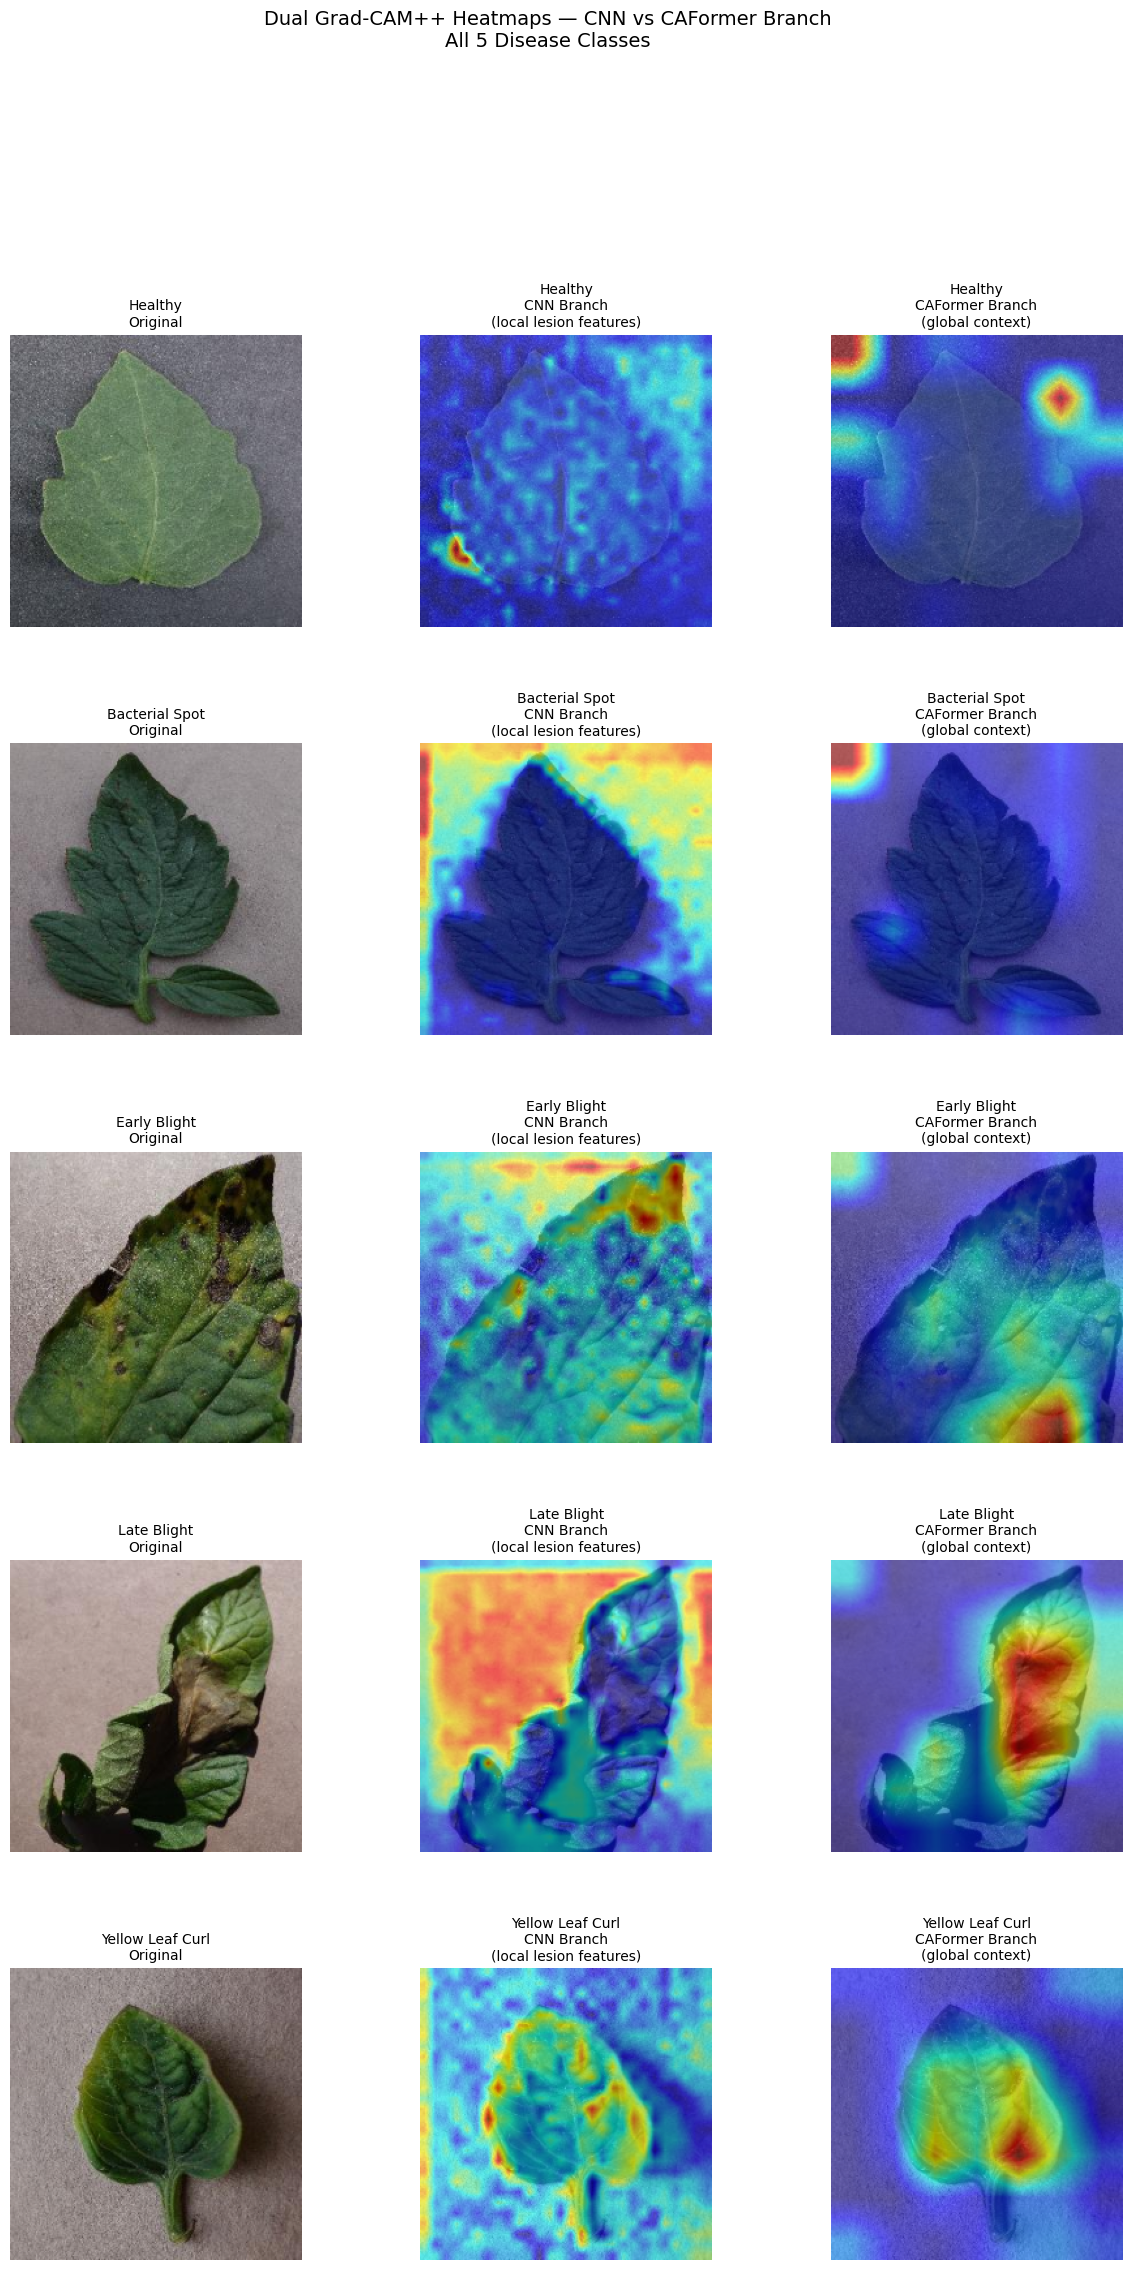


All heatmaps saved to Drive/project/results/gradcam/


In [15]:
fig = plt.figure(figsize=(15, 25))
gs  = gridspec.GridSpec(5, 3, figure=fig, hspace=0.4)

print("Generating heatmaps for all 5 classes...")

for row_idx, cls in enumerate(SELECTED_CLASSES):
    class_idx  = class_to_idx[cls]
    class_name = short_names[row_idx]
    img_path   = sample_images[cls]

    print(f"  Processing {class_name}...")

    img_float, cnn_heatmap, trans_heatmap = generate_dual_heatmap(
        img_path, class_idx, class_name
    )

    # Column 1 — Original image
    ax1 = fig.add_subplot(gs[row_idx, 0])
    ax1.imshow(img_float)
    ax1.set_title(f'{class_name}\nOriginal', fontsize=10)
    ax1.axis('off')

    # Column 2 — CNN Grad-CAM++ heatmap
    ax2 = fig.add_subplot(gs[row_idx, 1])
    ax2.imshow(cnn_heatmap)
    ax2.set_title(f'{class_name}\nCNN Branch\n(local lesion features)', fontsize=10)
    ax2.axis('off')

    # Column 3 — CAFormer Grad-CAM++ heatmap
    ax3 = fig.add_subplot(gs[row_idx, 2])
    ax3.imshow(trans_heatmap)
    ax3.set_title(f'{class_name}\nCAFormer Branch\n(global context)', fontsize=10)
    ax3.axis('off')

    # Save individual heatmaps too
    fig_individual, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_float);       axes[0].set_title('Original');          axes[0].axis('off')
    axes[1].imshow(cnn_heatmap);     axes[1].set_title('CNN Grad-CAM++');    axes[1].axis('off')
    axes[2].imshow(trans_heatmap);   axes[2].set_title('CAFormer Grad-CAM++'); axes[2].axis('off')
    plt.suptitle(f'{class_name} — Dual Branch Heatmaps', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(GRADCAM_DIR, f'gradcam_{cls}.png'), dpi=150)
    plt.close(fig_individual)

# Save full grid
plt.suptitle('Dual Grad-CAM++ Heatmaps — CNN vs CAFormer Branch\nAll 5 Disease Classes',
             fontsize=14, y=1.01)
plt.savefig(os.path.join(GRADCAM_DIR, 'gradcam_all_classes.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("\nAll heatmaps saved to Drive/project/results/gradcam/")

In [18]:

print("""
CNN branch
  Should highlight SMALL LOCAL regions
  Hot spots on lesion edges, spots, texture patches
  For Bacterial Spot: tiny scattered hot spots
  For Early Blight: edges of circular lesion rings
  For Late Blight: irregular patch boundaries

CAFormer Branch
  Should highlight BROADER REGIONS
  Hot areas spread across larger leaf sections
  For Yellow Leaf Curl: whole leaf yellowing pattern
  For Late Blight: overall affected area extent
  For Healthy: diffuse attention across full leaf

""")


CNN branch
  Should highlight SMALL LOCAL regions
  Hot spots on lesion edges, spots, texture patches
  For Bacterial Spot: tiny scattered hot spots
  For Early Blight: edges of circular lesion rings
  For Late Blight: irregular patch boundaries

CAFormer Branch
  Should highlight BROADER REGIONS
  Hot areas spread across larger leaf sections
  For Yellow Leaf Curl: whole leaf yellowing pattern
  For Late Blight: overall affected area extent
  For Healthy: diffuse attention across full leaf


